[1.00000000e-03 3.59381366e-03 1.29154967e-02 4.64158883e-02
 1.66810054e-01 5.99484250e-01 2.15443469e+00 7.74263683e+00
 2.78255940e+01 1.00000000e+02]
Calculated IC50: 2.32 uM
Calculated Hill Slope: 1.06


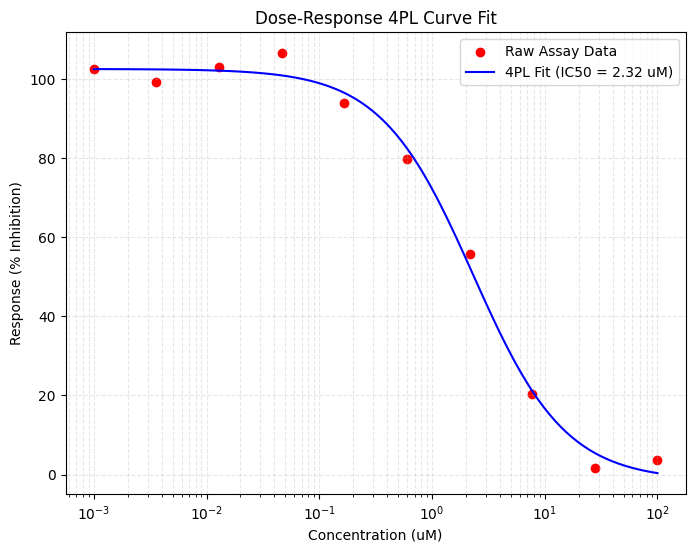

In [13]:
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Define the 4PL Equation
def four_param_logistic(x, A, B, C, D):
    """
    Computes the 4PL equation.
    """
    return A + ((D - A) / (1.0 + (x / C)**B))

# 2. Generate Synthetic "Messy" Data
# Create a 10-point concentration series (e.g., 0.001 uM to 100 uM)
concentrations = np.logspace(-3, 2, num = 10)
print (concentrations)

#3. Set true parameters to generate an ideal curve
#Bottom = 0, top = 1.2, IC50 = 2 uM , top = 100
true_params = [0, 1.2,2,100]
ideal_responses = four_param_logistic(concentrations,*true_params)

# 4. Add random noise
np.random.seed(42) 
noisy_responses = ideal_responses + np.random.normal(0, 5, size=len(concentrations))

#5. Initial guesses
initial_guesses = [min(noisy_responses), 1.0, np.median(concentrations), max(noisy_responses)]

# Set logical boundaries so the math doesn't produce impossible biology 
# Format: ([lower_A, lower_B, lower_C, lower_D], [upper_A, upper_B, upper_C, upper_D])
param_bounds = (
    [-np.inf, 0.1, 1e-5, -np.inf], # Slope and IC50 must be positive
    [np.inf, 5.0, 1e5, np.inf]     
)

#Performing the regression

popt, pcov = curve_fit(four_param_logistic, 
    concentrations, 
    noisy_responses, 
    p0=initial_guesses,
    bounds=param_bounds
)

# Extract the fitted parameters
fit_A, fit_B, fit_C, fit_D = popt
print(f"Calculated IC50: {fit_C:.2f} uM")
print(f"Calculated Hill Slope: {fit_B:.2f}")

# 4. Visualize the Results
# Generate a smooth line consisting of 100 points for the fitted curve
x_smooth = np.logspace(np.log10(min(concentrations)), np.log10(max(concentrations)), 100)
y_smooth = four_param_logistic(x_smooth, *popt)

plt.figure(figsize=(8, 6))
plt.scatter(concentrations, noisy_responses, color='red', label='Raw Assay Data')
plt.plot(x_smooth, y_smooth, color='blue', label=f'4PL Fit (IC50 = {fit_C:.2f} uM)')

# Dose-response curves must be plotted with a logarithmic X-axis
plt.xscale('log') 
plt.xlabel('Concentration (uM)')
plt.ylabel('Response (% Inhibition)')
plt.title('Dose-Response 4PL Curve Fit')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()
    